# Фиксированная и случайная длительность инфекции
Дополнительное задание 2. Средняя длительность равна 1/γ=4 дня.
В варианте fixed каждый заразный выздоравливает ровно через 4 дня;
в exponential длительность случайна. Два базовых опыта имеют seed=1234.

In [1]:
using DrWatson
@quickactivate "project"
using project.SIRDES
using CSV, DataFrames, Statistics, StatsPlots
include(srcdir("experiments.jl"))
using .Experiments

In [2]:
rows=NamedTuple[]
fig=plot(;xlabel="Time",ylabel="I",title="Infectious duration, seed=1234",size=(950,550))
for fixed in (false,true), rep in 1:20
    seed=rep==1 ? 1234 : 3000+rep
    model,result=simulate(family="duration",seed=seed,fixed_duration=fixed)
    push!(rows,result)
    if rep==1
        plot!(fig,model.ta,model.Ia;label=fixed ? "fixed 4 days" : "exponential mean 4",lw=2)
        save_table("duration-"*(fixed ? "fixed" : "exponential"),
            DataFrame(duration=model.disease_durations))
    end
end
runs=save_table("duration-runs",DataFrame(rows));

Row,fixed,replicates,peak_mean,peak_sd,peak_time_mean,R_fraction_mean,infected_mean,I_T_mean,extinction_fraction
,Bool,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,false,20,166.25,20.2611,18.655,0.76115,777.55,16.4,0.0
2,true,20,326.05,27.6757,11.2092,0.8129,812.9,0.0,1.0


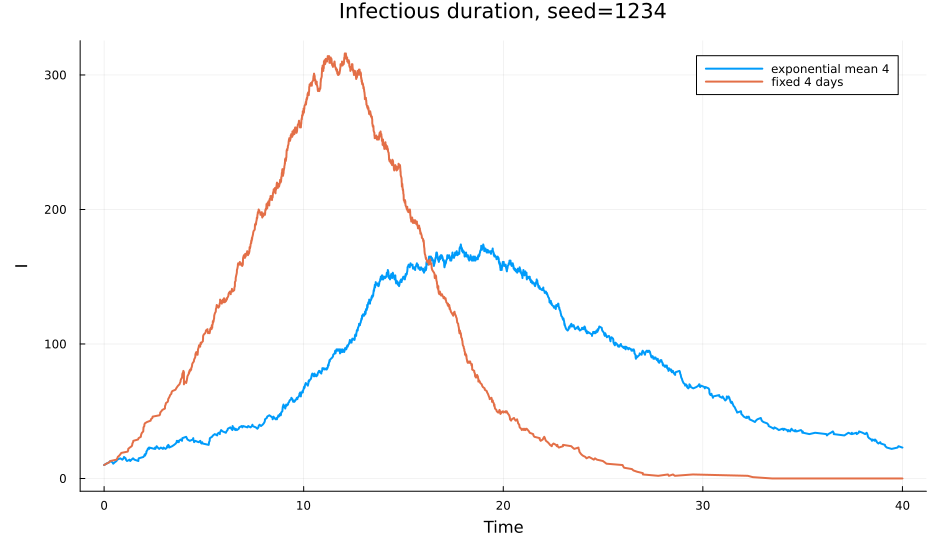

In [3]:
summary=save_table("duration-summary",summarize(runs,[:fixed]))
display(summary)
savefig(fig,figure_path("04-plot"))
display(fig)

## Наблюдённые длительности
Таблица содержит только завершённые инфекции. Невыздоровевшие к T
цензурированы; её среднее не является несмещённой оценкой закона ожидания.

Row,law,completed,observed_mean
,String,Int64,Float64
1,fixed,833,4.0
2,exponential,751,4.00933


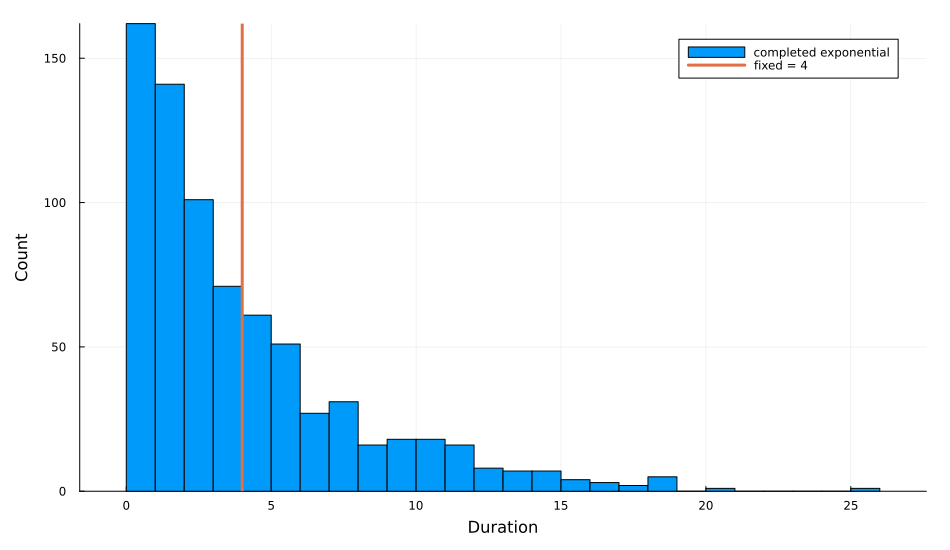

In [4]:
fixed_data=CSV.read(datadir("analysis","duration-fixed.csv"),DataFrame)
exp_data=CSV.read(datadir("analysis","duration-exponential.csv"),DataFrame)
@assert all(isapprox.(fixed_data.duration,4.0;atol=1e-10))
display(DataFrame(law=["fixed","exponential"],
    completed=[nrow(fixed_data),nrow(exp_data)],
    observed_mean=[mean(fixed_data.duration),mean(exp_data.duration)]))
fig2=histogram(exp_data.duration;bins=25,label="completed exponential",
    xlabel="Duration",ylabel="Count",size=(950,550))
vline!(fig2,[4.0];label="fixed = 4",lw=3)
savefig(fig2,figure_path("05-plot"))
display(fig2)